In [31]:
# Matplotlib 
# the individual plot area that containes the x-axis & y-axis
# for x-axis one type data, for 2d graph need two type data x-axis and y-axis, 3d graph need three type data x-axis, y-axis, z-axis
# we also make multiple small graph
# matplotlib provide stateful( pyplot style) functions operate on the current figure & axis (plt.plot())
# onject oriented uses explitcit figure & axes objects for grater control 
# prefer the object oriented style for resuable & complex plots
# label the x-axis & y-axis
# use descriptive labels for plots

# we use line plot when we want to show linear relation between two data
# we use scater plot when we want to show random relation between two data

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

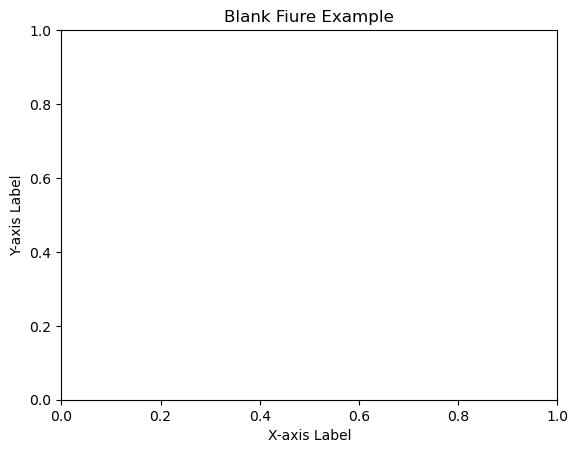

In [4]:
fig, ax = plt.subplots() # object oriented workflow
# lables axes
ax.set_title("Blank Fiure Example")
ax.set_xlabel("X-axis Label")
ax.set_ylabel("Y-axis Label")

# save to PNG
fig.savefig("blank_plot.png",dpi=100)
plt.show()

In [5]:
# Line & Scatter Plots Basics
# Line plots use for small amount of points and Scatter plot use for high amount of points

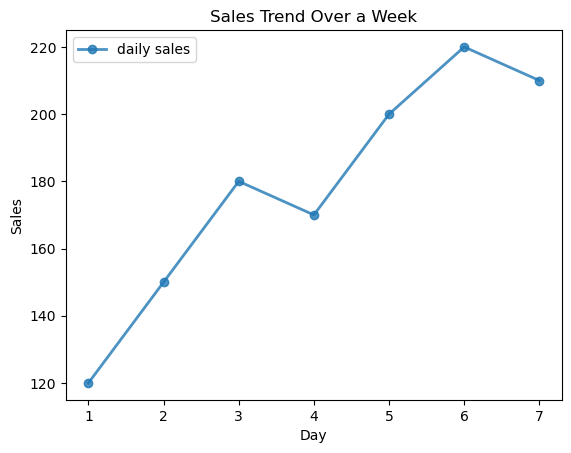

In [6]:
# Sample data for line plot
days = [1,2,3,4,5,6,7]
sales=[120,150,180,170,200,220,210]

plt.plot(days,sales,
    marker='o',
    linewidth=2,
    alpha=0.8, # transparency
    label="daily sales")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Sales Trend Over a Week")
plt.legend() # legend show as side of figure
plt.show()

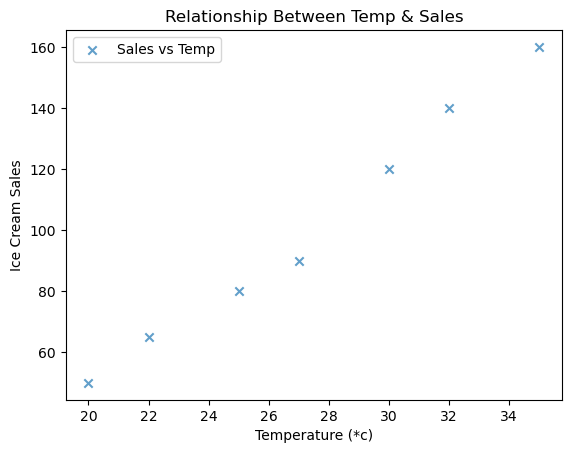

In [7]:
# sample data for Scatter plot
temperature = [20,22,25,27,30,32,35]
ice_cream_sales=[50,65,80,90,120,140,160]
plt.scatter(temperature,ice_cream_sales,
            alpha = 0.7,
            marker = 'x',
            label="Sales vs Temp")
plt.xlabel("Temperature (*c)")
plt.ylabel("Ice Cream Sales")
plt.title("Relationship Between Temp & Sales")
plt.legend()
plt.show()

In [8]:
df = pd.read_csv("./files/ecommerce_sales_analytics_5000.csv",parse_dates=["order_date"])
df = df.sample(n=100)

Text(0, 0.5, 'Total Revenue')

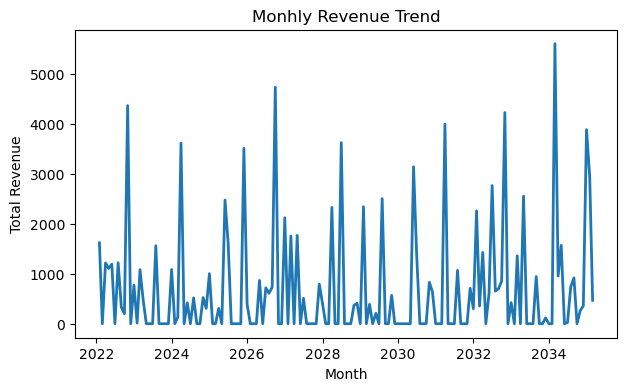

In [9]:
# line plot - monthly revenue trend
monthly_revenue = (df
                   .set_index("order_date")["revenue"]
                   .resample('ME')
                   .sum()
                  )
fid,ax = plt.subplots(figsize = (7,4))
ax.plot(monthly_revenue.index,monthly_revenue.values,linewidth=2)

ax.set_title("Monhly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
# explanation: line connects revenue over time and show growth or decline clearly

Text(0, 0.5, 'Revenue')

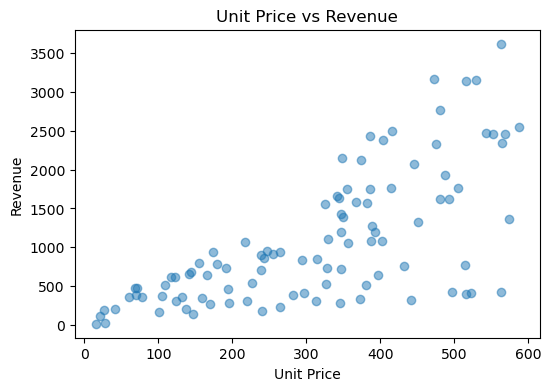

In [10]:
# Scatter plot - Discoun vs revenue
fig,ax = plt.subplots(figsize=(6,4))
ax.scatter(df["unit_price"],df["revenue"],alpha= 0.5)
ax.set_title("Unit Price vs Revenue")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Revenue")

# each point = one order and transparency (alpha) helps with overlapping points

In [11]:
# Bar charts in matplotlib- simple, grouped...
# bar charts use show data in the form of bar
# it show effectiveness when data is grouped

Text(0, 0.5, 'Total Revenue')

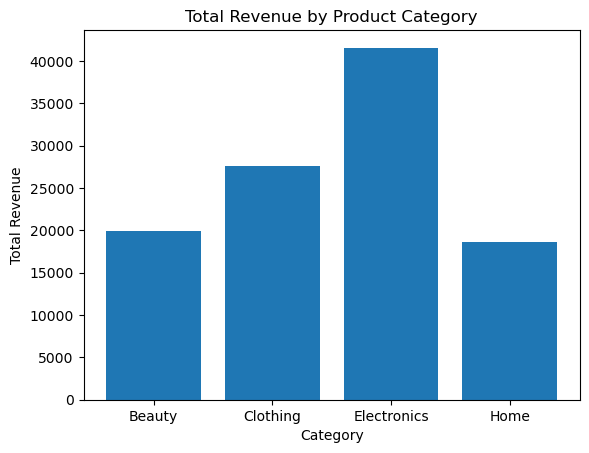

In [12]:
# simple bar chat - revenue by product category
category_revenue = df.groupby("product_category")["revenue"].sum()

fig,ax = plt.subplots()
ax.bar(category_revenue.index,category_revenue.values)

ax.set_title("Total Revenue by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue")

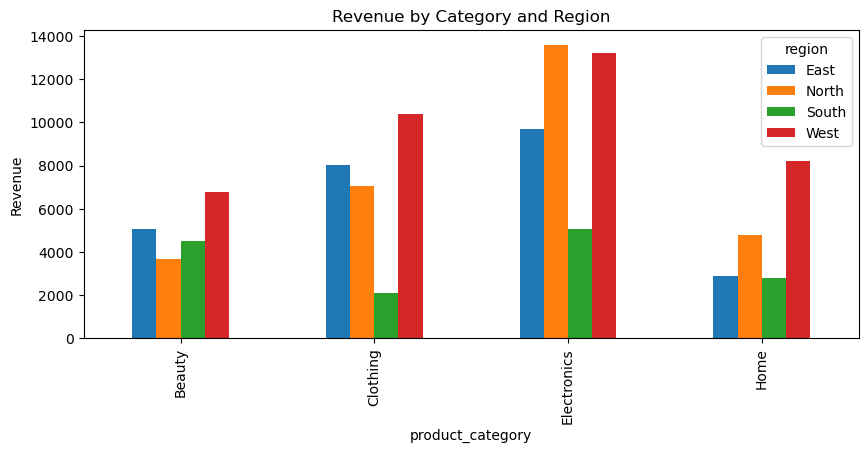

In [13]:
# grouped bar chart - revenue by category & region
grouped = df.groupby(["product_category","region"])["revenue"].sum().unstack()

grouped.plot(kind="bar",figsize=(10,4))
plt.title("Revenue by Category and Region")
plt.ylabel("Revenue")
plt.show()

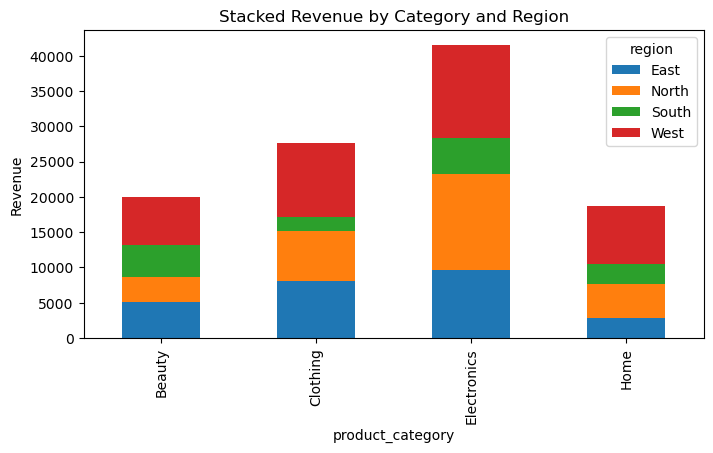

In [14]:
# stacked bar chart
grouped.plot(kind="bar",stacked=True,figsize=(8,4))
plt.title("Stacked Revenue by Category and Region")
plt.ylabel("Revenue")
plt.show()

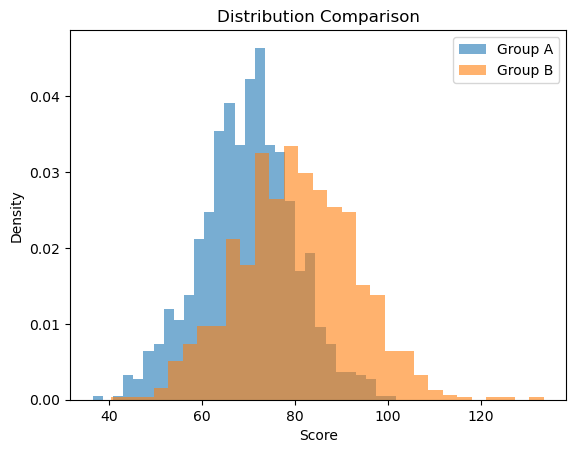

In [15]:
# Histograms & Density Plots, to judge frequency of data
group_a = np.random.normal(70,10,1000) # mean, standard deviation, number of random sample
group_b= np.random.normal(80,12,1000)

plt.hist(group_a,bins = 30,density=True,
         alpha = 0.6, label="Group A")
plt.hist(group_b,bins = 30,density=True,
         alpha = 0.6, label="Group B")

plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution Comparison")
plt.legend()
plt.show()

In [16]:
# use working dataset
df = pd.read_csv("./files/ecommerce_sales_analytics_5000.csv",parse_dates=["order_date"])
df = df.sample(n=1000)

Text(0, 0.5, 'Frequency')

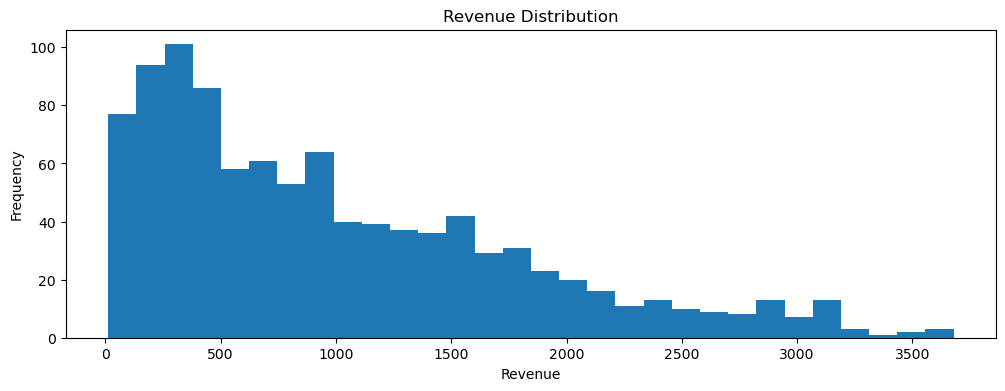

In [17]:
# Histogram - Revenue Distribution
fig,ax = plt.subplots(figsize=(12,4))
ax.hist(df["revenue"],bins=30)

ax.set_title("Revenue Distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Frequency")

Text(0, 0.5, 'Density')

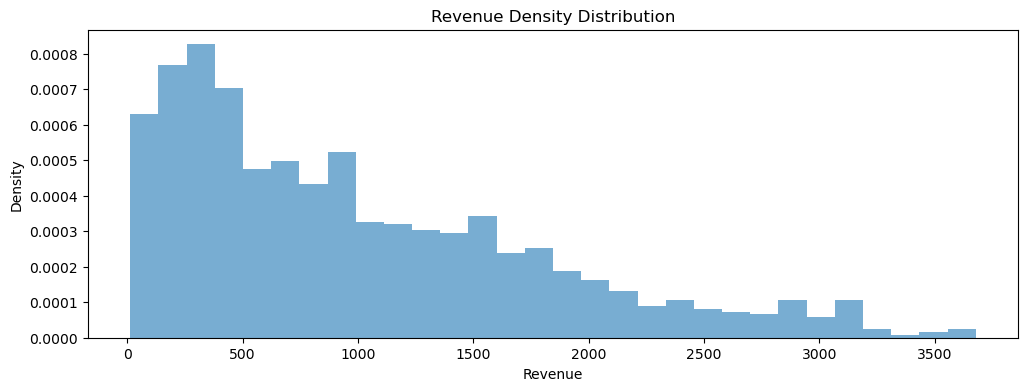

In [18]:
# density plot
fid,ax = plt.subplots(figsize=(12,4))
ax.hist(df["revenue"],bins=30,density=True,alpha=0.6)

ax.set_title("Revenue Density Distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Density")

Text(0.5, 1.0, 'Revenue Comparison')

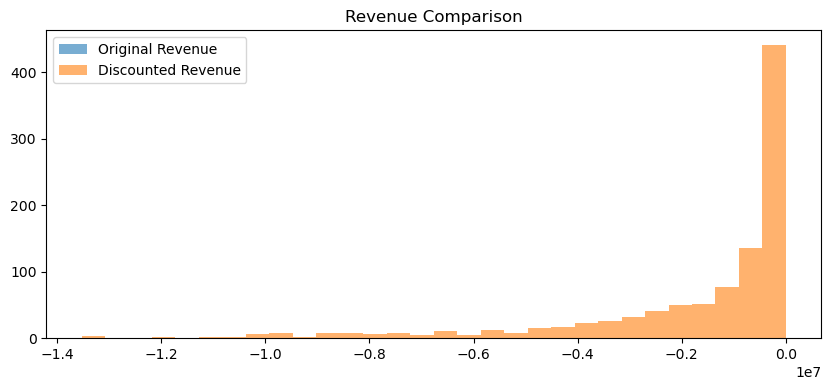

In [19]:
# overlay two histogram (comparison) - revenue vs discounted revenue
discounted_revenue = df["revenue"]*(1 - df["revenue"])

fig,ax = plt.subplots(figsize=(10,4))
ax.hist(df["revenue"],bins=30, alpha=0.6, label="Original Revenue")
ax.hist(discounted_revenue,bins=30,alpha=0.6, label="Discounted Revenue")

ax.legend()
ax.set_title("Revenue Comparison")

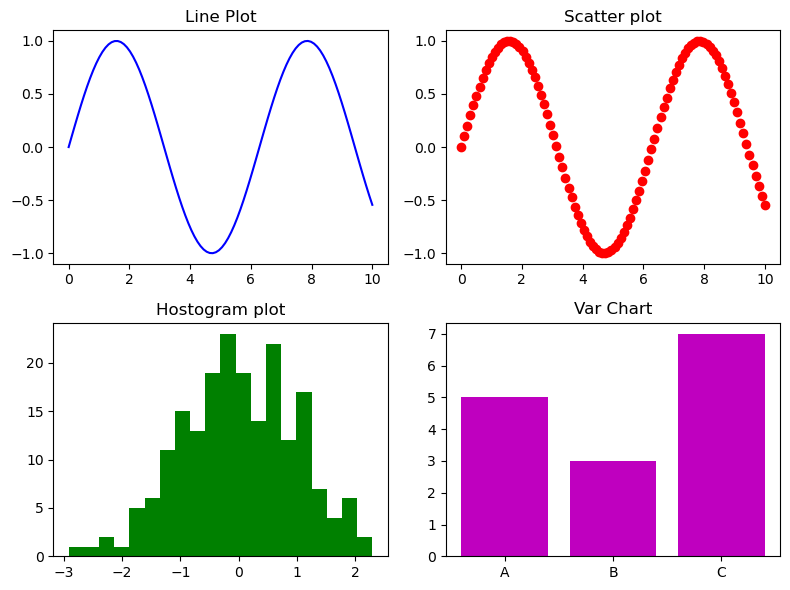

In [24]:
# create subplots & layout  , we use it for related plot or data
x = np.linspace(0,10,100)
y= np.sin(x)
fig, axs = plt.subplots(2,2,figsize=(8,6)) # 2 by 2 grid mean 4 subplots
# line plot
axs[0,0].plot(x,y,color="b")
axs[0,0].set_title("Line Plot")

# Scatter plot
axs[0,1].scatter(x,y,color="r")
axs[0,1].set_title("Scatter plot")

#Histogram
axs[1,0].hist(np.random.randn(200),bins=20,color="g")
axs[1,0].set_title("Hostogram plot")

# bar chart
categories = ["A","B","C"]
values = [5,3,7]
axs[1,1].bar(categories,values,color="m")
axs[1,1].set_title("Var Chart")

plt.tight_layout() # for spacing reduce
plt.show()


In [25]:
df = pd.read_csv("./files/ecommerce_sales_analytics_5000.csv",parse_dates = ["order_date"])

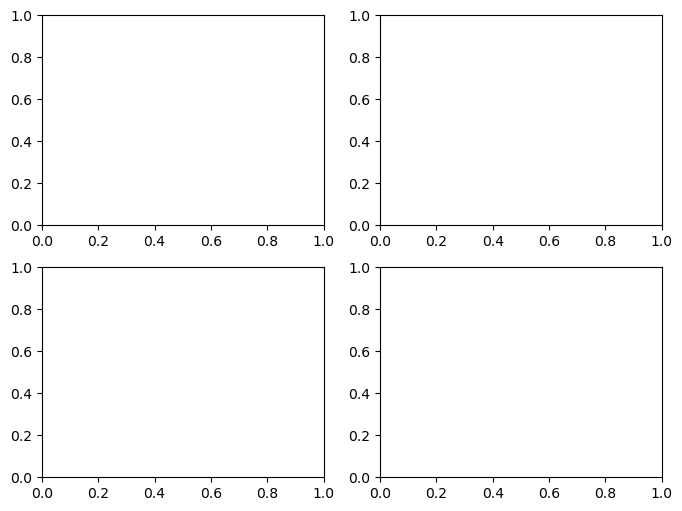

In [27]:
# Basic subplots grid 2x2
fig ,axes = plt.subplots(2,2,figsize=(8,6))

In [28]:
axes[0,1]
axes[1,1]

<Axes: >

In [29]:
# Hands on dashboard example

Text(0.5, 1.0, 'Customer rating distribution')

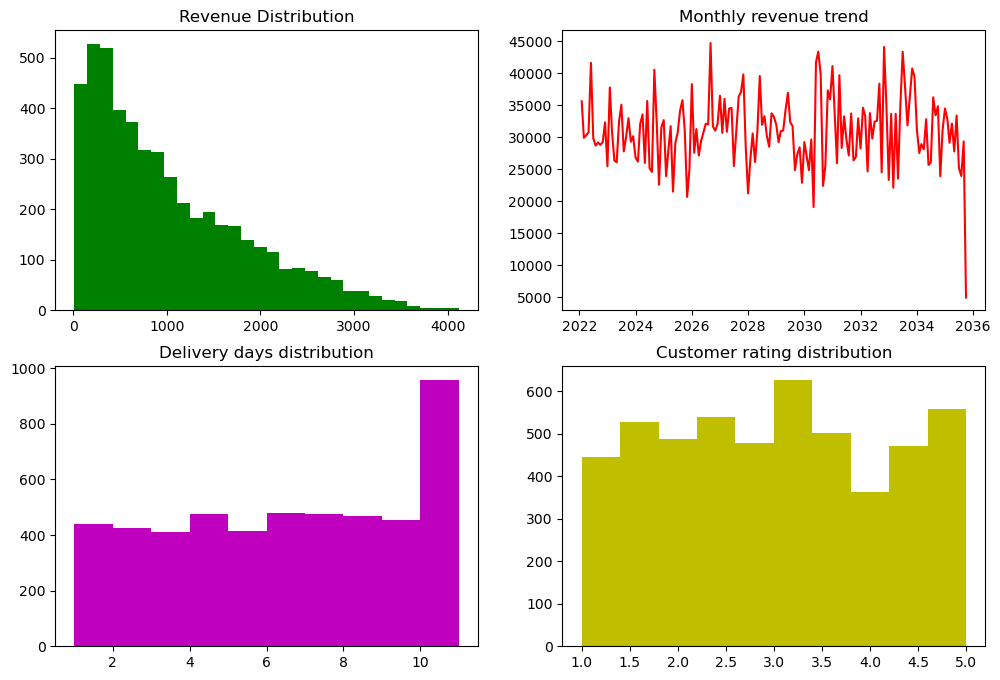

In [33]:
fig,axes  = plt.subplots(2,2,figsize=(12,8))

# revenue distribution
axes[0,0].hist(df["revenue"],bins=30,color="g")
axes[0,0].set_title("Revenue Distribution")

# monthly revenue trend
monthly = (
    df.set_index("order_date")["revenue"]
    .resample('ME').sum()
)
axes[0,1].plot(monthly.index,monthly.values,color="r")
axes[0,1].set_title("Monthly revenue trend")

# delivery days
axes[1,0].hist(df["delivery_days"],bins=10,color="m")
axes[1,0].set_title("Delivery days distribution")

# customer rating
axes[1,1].hist(df["customer_rating"],bins=10,color="y")
axes[1,1].set_title("Customer rating distribution")

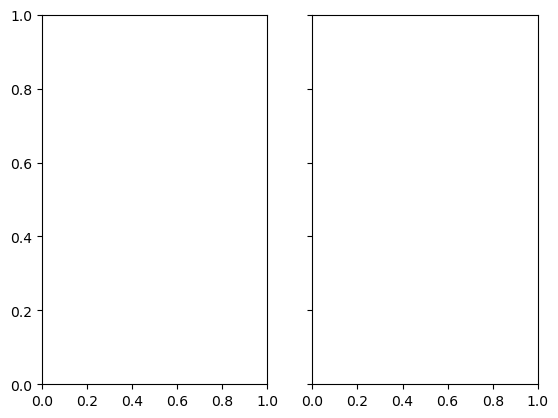

In [34]:
# shared axes (sharex,sharey)
fig,axes = plt.subplots(1,2,sharey=True)

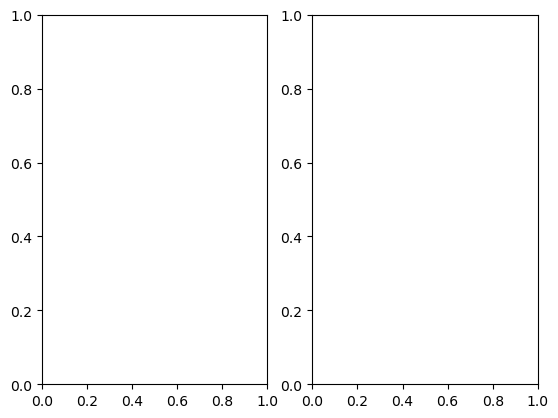

In [35]:
fig,axes = plt.subplots(1,2,sharey=False)


<function matplotlib.pyplot.show(close=None, block=None)>

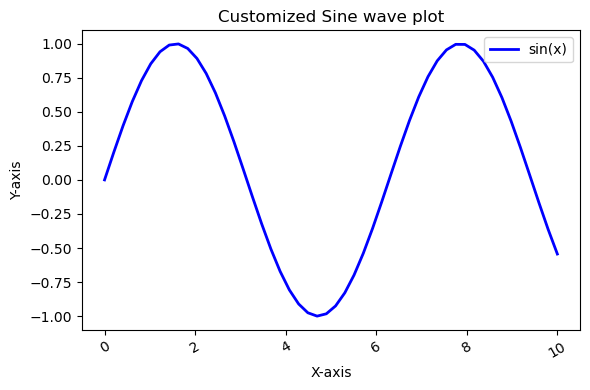

In [38]:
# Customizing & exporting matplotlib 
x = np.linspace(0,10,50)
y = np.sin(x)

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(x,y,label="sin(x)",color="b",linewidth=2)

# customize ticks and rotation
ax.set_xticks(range(0,11,2))
plt.xticks(rotation=30)

# legend placement
ax.legend(loc="upper right")

# labels & title
ax.set_title("Customized Sine wave plot")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")

#save polished figure
plt.tight_layout()
plt.savefig("sine_plot.png",dpi=300,format="png")
plt.show

In [39]:
# load dataset
df = pd.read_csv("./files/ecommerce_sales_analytics_5000.csv",parse_dates = ["order_date"])


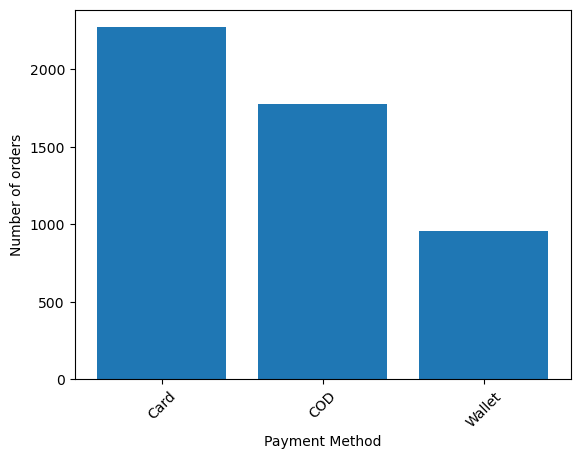

In [43]:
# ticks & tick labels
fig,ax = plt.subplots()
ax.bar(
    df["payment_method"].value_counts().index,
    df["payment_method"].value_counts().values
)

ax.set_xlabel("Payment Method")
ax.set_ylabel("Number of orders")
ax.tick_params(axis="x",rotation=45)
plt.show()

Text(0, 0.5, 'Revenue')

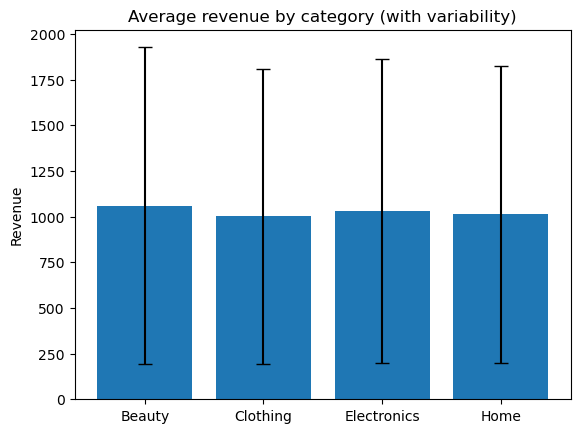

In [46]:
# Error bars & confidence intervals in plots 
# error bars - mean revenue by product category
stats = df.groupby("product_category")["revenue"].agg(["mean","std"])  # std mean standard deviation

fig,ax = plt.subplots()
ax.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5
)

ax.set_title("Average revenue by category (with variability)")
ax.set_ylabel("Revenue")

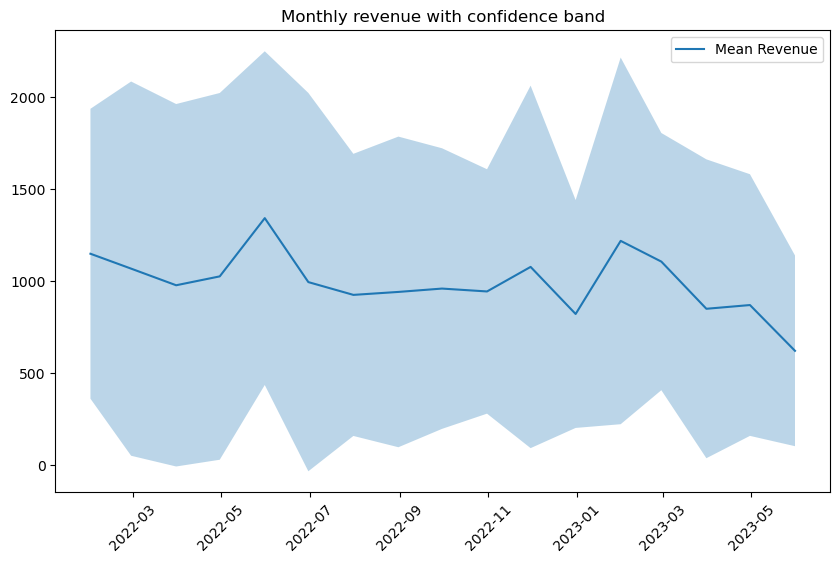

In [54]:
# confidence bands - monthly revenue trend with variability
df = df.head(n=500)
monthly = (
    df.set_index("order_date")["revenue"]
    .resample('ME')
    .agg(["mean","std"])
)
fig,ax = plt.subplots(figsize=(10,6))
ax.plot(monthly.index,monthly["mean"],label="Mean Revenue")

ax.fill_between(
    monthly.index,
    monthly["mean"]-monthly["std"],
    monthly["mean"]+monthly["std"],
    alpha = 0.3
)
ax.tick_params(axis="x",rotation=45)
ax.set_title("Monthly revenue with confidence band")
ax.legend()